# 09 — Comparing Generative Architectures: GAN vs VAE

## 📚 Learning Objectives

By completing this notebook, you will:
- Train a GAN **and** a VAE on the *same* data with the *same* budget
- Compare their samples side by side against real data
- Quantify the comparison with two computed measures: **sharpness** (pixel-gradient strength) and **diversity** (mean pairwise sample distance)
- Know when to choose which architecture

## 🔗 Where this fits

**Builds on:** Course 10 — Unit 1, lessons 04 and 05 (the VAE and the GAN) — both are retrained here on one dataset with one budget, which is the only fair way to compare.

**Used later in:** Course 10 — Unit 1, lesson 10, which replaces eyeballing with FID.

---

## Introduction

Examples 04 and 05 built the two core deep generative architectures separately. Here we put them head-to-head under identical conditions — same MNIST subset, same number of passes over the data — and look at the outputs like a reviewer would: a sample grid plus honest numbers.

**Background expectations** (from the literature — the point of this notebook is to *check* them on our own models):
- GANs' adversarial loss tends to produce **sharper** samples; VAEs' pixel-wise reconstruction loss tends to produce **blurrier** ones.
- VAEs cover the data distribution well; GANs can drop modes.

---

## 🌍 Why this lesson exists — the comparison the field ran at scale, in 2022

This head-to-head is a small version of the comparison the whole field ran between 2020 and 2022, and the result is worth knowing before you look at your own numbers: **neither contestant won.** Stability AI shipped Stable Diffusion as latent diffusion (Rombach et al., 2022, arXiv 2112.10752), not as a GAN and not as a VAE — although it uses a VAE *inside* it, as a compressor. GANs stayed strong on narrow aligned domains (faces) and diffusion took open-ended generation. The VAE survived as a component, not as a generator.

**What goes wrong without this:** without a controlled comparison — same data, same budget, same seed discipline — architecture arguments get settled by whoever cherry-picked their demo hardest. Fixing the data and the budget, as this notebook does, is the only thing that makes the numbers mean anything at all.


Training VAE...


  final VAE loss/image: 114.5
Training GAN...


  final D loss: 0.656  G loss: 2.615


/var/folders/7n/l2c2z2x57871xg4f_0drsv1m0000gn/T/ipykernel_53050/3222040124.py:87: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(); plt.show()


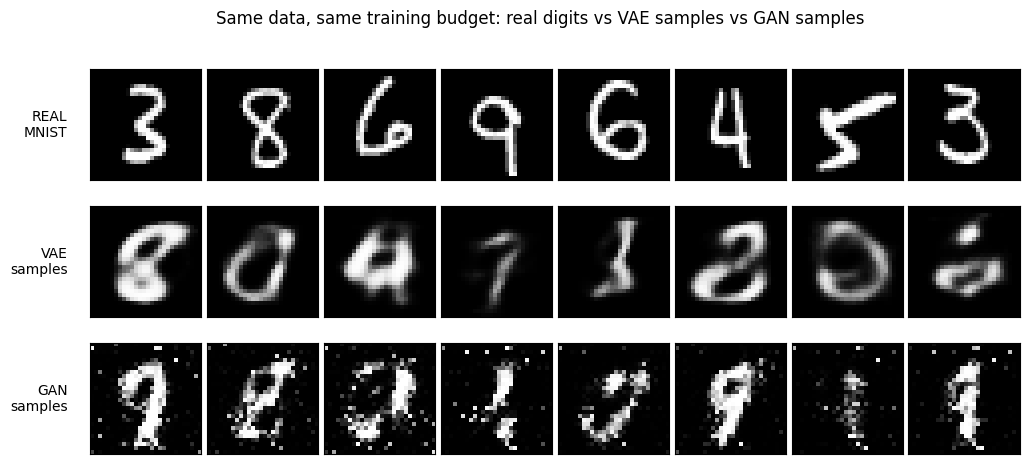


           sharpness   diversity
real       0.0646      9.56
VAE        0.0500      7.57
GAN        0.0978      8.19

How to read (always against the REAL row):
  sharpness BELOW real  = blur (the classic VAE artifact);
  sharpness ABOVE real  = speckle/noise, not true detail — a small-GAN
                          artifact; confirm against the sample grid;
  diversity below real  = samples repeating themselves (mode dropping).
Metrics summarize — the grid is the ground truth for what they mean.


In [1]:
# WHAT/WHY: train a GAN and a VAE on the same 12,800-digit MNIST subset,
# then produce (a) a real/VAE/GAN sample grid and (b) two computed metrics —
# sharpness and diversity — so the architecture comparison rests on evidence
# from THIS run, not just received wisdom.
import torch, torch.nn as nn, torch.nn.functional as F, torch.optim as optim
import torchvision, torchvision.transforms as T
import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(42)
LATENT = 16; LATENT_GAN = 64; BATCH = 128; N_IMG = 12_800

# ── Shared data (VAE uses [0,1]; GAN uses [-1,1] for its Tanh output) ─────
ds01 = torchvision.datasets.MNIST('./data/mnist', train=True, download=True, transform=T.ToTensor())
ds11 = torchvision.datasets.MNIST('./data/mnist', train=True, download=True,
                                  transform=T.Compose([T.ToTensor(), T.Normalize([0.5], [0.5])]))
loader01 = torch.utils.data.DataLoader(torch.utils.data.Subset(ds01, range(N_IMG)), batch_size=BATCH, shuffle=True)
loader11 = torch.utils.data.DataLoader(torch.utils.data.Subset(ds11, range(N_IMG)), batch_size=BATCH, shuffle=True)

# ── VAE (architecture from example 04) ────────────────────────────────────
class VAE(nn.Module):
    def __init__(self, z=LATENT):
        super().__init__()
        self.enc    = nn.Sequential(nn.Flatten(), nn.Linear(784, 256), nn.ReLU())
        self.mu     = nn.Linear(256, z)
        self.logvar = nn.Linear(256, z)
        self.dec    = nn.Sequential(nn.Linear(z, 256), nn.ReLU(), nn.Linear(256, 784), nn.Sigmoid())
    def forward(self, x):
        h = self.enc(x)
        mu, logvar = self.mu(h), self.logvar(h)
        z = mu + torch.exp(0.5 * logvar) * torch.randn_like(mu)   # reparameterize
        return self.dec(z).view(-1, 1, 28, 28), mu, logvar

vae = VAE(); opt_v = optim.Adam(vae.parameters(), lr=1e-3)
EPOCHS = 20  # same number of data passes for both models
print("Training VAE...")
for epoch in range(EPOCHS):
    for x, _ in loader01:
        recon, mu, logvar = vae(x)
        loss = (F.binary_cross_entropy(recon, x, reduction='sum')
                - 0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())) / x.size(0)
        opt_v.zero_grad(); loss.backward(); opt_v.step()
print(f"  final VAE loss/image: {loss.item():.1f}")

# ── GAN (architecture from example 05) ────────────────────────────────────
G = nn.Sequential(nn.Linear(LATENT_GAN, 256), nn.LeakyReLU(0.2),
                  nn.Linear(256, 512), nn.LeakyReLU(0.2),
                  nn.Linear(512, 784), nn.Tanh())
D = nn.Sequential(nn.Linear(784, 512), nn.LeakyReLU(0.2), nn.Dropout(0.3),
                  nn.Linear(512, 256), nn.LeakyReLU(0.2), nn.Dropout(0.3),
                  nn.Linear(256, 1), nn.Sigmoid())
opt_G = optim.Adam(G.parameters(), lr=2e-4, betas=(0.5, 0.999))
opt_D = optim.Adam(D.parameters(), lr=2e-4, betas=(0.5, 0.999))
bce = nn.BCELoss()
print("Training GAN...")
for epoch in range(EPOCHS):
    for real, _ in loader11:
        bs = real.size(0); flat = real.view(bs, -1)
        fake = G(torch.randn(bs, LATENT_GAN)).detach()
        lD = bce(D(flat), torch.ones(bs, 1)) + bce(D(fake), torch.zeros(bs, 1))
        opt_D.zero_grad(); lD.backward(); opt_D.step()
        fake = G(torch.randn(bs, LATENT_GAN))
        lG = bce(D(fake), torch.ones(bs, 1))
        opt_G.zero_grad(); lG.backward(); opt_G.step()
print(f"  final D loss: {lD.item():.3f}  G loss: {lG.item():.3f}")

# ── Sample 64 images from each model (+ 64 real ones for reference) ───────
vae.eval(); G.eval()
with torch.no_grad():
    vae_imgs = vae.dec(torch.randn(64, LATENT)).view(-1, 28, 28)           # in [0,1]
    gan_imgs = (G(torch.randn(64, LATENT_GAN)).view(-1, 28, 28) + 1) / 2   # map to [0,1]
real_imgs = torch.stack([ds01[i][0] for i in range(50_000, 50_064)]).squeeze(1)

# ── Sample grid: real vs VAE vs GAN, 8 each ───────────────────────────────
fig, axes = plt.subplots(3, 8, figsize=(12, 5.2),
                         gridspec_kw=dict(hspace=0.08, wspace=0.05))
row_labels = ["REAL\nMNIST", "VAE\nsamples", "GAN\nsamples"]
for j in range(8):
    for row, imgs in enumerate([real_imgs, vae_imgs, gan_imgs]):
        # set_xticks/set_yticks rather than axis('off'): axis('off') would also
        # hide the row label, and an unlabelled row cannot be compared.
        axes[row, j].imshow(imgs[j], cmap='gray', vmin=0, vmax=1)
        axes[row, j].set_xticks([]); axes[row, j].set_yticks([])
for row, lab in enumerate(row_labels):
    axes[row, 0].set_ylabel(lab, fontsize=10, rotation=0, ha='right', va='center', labelpad=16)
plt.suptitle("Same data, same training budget: real digits vs VAE samples vs GAN samples")
plt.tight_layout(); plt.show()

# ── Metric 1: sharpness — mean absolute pixel gradient (higher = sharper) ─
def sharpness(imgs):
    gx = (imgs[:, :, 1:] - imgs[:, :, :-1]).abs().mean()
    gy = (imgs[:, 1:, :] - imgs[:, :-1, :]).abs().mean()
    return ((gx + gy) / 2).item()

# ── Metric 2: diversity — mean pairwise L2 distance between samples ───────
def diversity(imgs):
    return torch.pdist(imgs.reshape(len(imgs), -1)).mean().item()

print("\n           sharpness   diversity")
for name, imgs in [("real", real_imgs), ("VAE ", vae_imgs), ("GAN ", gan_imgs)]:
    print(f"{name}       {sharpness(imgs):.4f}      {diversity(imgs):.2f}")
print("\nHow to read (always against the REAL row):")
print("  sharpness BELOW real  = blur (the classic VAE artifact);")
print("  sharpness ABOVE real  = speckle/noise, not true detail — a small-GAN")
print("                          artifact; confirm against the sample grid;")
print("  diversity below real  = samples repeating themselves (mode dropping).")
print("Metrics summarize — the grid is the ground truth for what they mean.")


**Read the three rows, then read the numbers.** All three rows are drawn on the same grey scale, so any difference you see is a difference in the images.

*Real.* Clean single strokes, smooth edges, a solid black background with nothing in it.

*VAE.* Every panel is a recognisable digit-ish shape, correctly placed and correctly proportioned — and every one of them is **soft**. The strokes fade into the background instead of ending, and the background itself is a dark grey wash rather than black. That is the pixel-wise reconstruction loss doing exactly what example 02 showed it must: when the decoder is unsure, hedging toward the average costs it less than committing.

*GAN.* The opposite failure. The strokes are bright and hard-edged — and the background is littered with **isolated white pixels** that no handwriting produces. Look along the black areas of the GAN row and count them; they are the whole reason the sharpness metric below scores this row *higher than real MNIST*. A pixel-gradient measure cannot tell "crisp stroke" from "single hot pixel next to a black one", and this row is full of the second kind.

That is the trap this notebook is really teaching: the GAN wins the sharpness number and loses the picture. Before you accept a metric, look at what it is measuring.

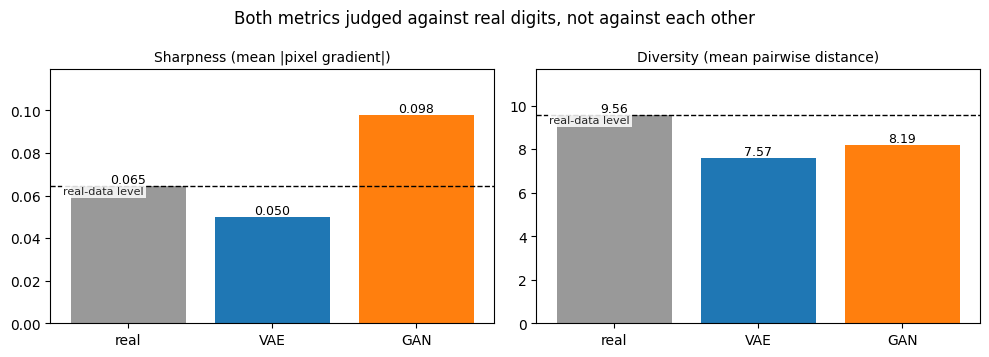

model   sharpness vs real      diversity vs real
VAE     -0.0146 (77%)     -1.99 (79%)
GAN     +0.0333 (151%)     -1.37 (86%)


In [2]:
# WHAT/WHY: the two metrics printed above are only meaningful RELATIVE to the
# real digits, so plot them that way: bars for each model with the real value
# drawn as the line they are supposed to sit on. Distance from that line, in
# either direction, is the artifact.
names = ["real", "VAE", "GAN"]
sets  = [real_imgs, vae_imgs, gan_imgs]
sharp = [sharpness(s) for s in sets]
divs  = [diversity(s) for s in sets]

fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))
for ax, vals, title in [(axes[0], sharp, "Sharpness (mean |pixel gradient|)"),
                        (axes[1], divs,  "Diversity (mean pairwise distance)")]:
    ax.bar(names, vals, color=["0.6", "tab:blue", "tab:orange"])
    ax.axhline(vals[0], ls='--', c='k', lw=1)          # the real-data reference line
    ax.set_title(title, fontsize=10)
    for i, v in enumerate(vals):
        ax.text(i, v, f"{v:.3f}" if max(vals) < 1 else f"{v:.2f}",
                ha='center', va='bottom', fontsize=9)
    ax.margins(y=0.22)
for ax, vals in [(axes[0], sharp), (axes[1], divs)]:
    # Label the reference line on both panels, tucked under it so it never
    # sits on top of a bar.
    ax.annotate("real-data level", xy=(-0.45, vals[0]), fontsize=8, va='top', ha='left',
                color='0.15', bbox=dict(fc='white', ec='none', alpha=0.85, pad=1.2))
plt.suptitle("Both metrics judged against real digits, not against each other")
plt.tight_layout(); plt.show()

print("model   sharpness vs real      diversity vs real")
for n, s, d in zip(names[1:], sharp[1:], divs[1:]):
    print(f"{n:<6}  {s - sharp[0]:+.4f} ({s/sharp[0]:.0%})     {d - divs[0]:+.2f} ({d/divs[0]:.0%})")

**Read each bar against the dashed line, not against the other bar.** The line is the real digits' value; being far from it is the defect, in either direction.

On sharpness the two models miss the line on opposite sides. The VAE sits **below** it — that is the blur its pixel-wise reconstruction loss is rewarded for, exactly the mechanism demonstrated in example 02. The GAN sits **above** it, and a generator cannot be sharper than reality: what the metric is picking up is high-frequency speckle in the samples, which the sample grid above confirms. This is the single most useful habit in this notebook — a metric that beats real data is a warning, not a win.

On diversity both models fall short of the real row, the VAE further than the GAN. Read that as "neither is covering the data as widely as the data covers itself" rather than as a ranking: pixel distance cannot tell a generator that dropped a digit class from one that produces every class slightly more conservatively. Example 10 is where the evaluation gets sharper than this.

## 💬 Discuss

1. Our GAN's sharpness is **0.0978 against real digits' 0.0646** — measured *above* reality. Is the GAN sharper than real data, or is something else happening? Argue from the sample grid, then say what you would report to a reviewer.
2. Diversity: real 9.56, VAE 7.57, GAN 8.19. Does that make the GAN more diverse than the VAE — or is pixel-space diversity the wrong yardstick for this question? Propose a better measurement and predict whether it would flip the ranking.
3. Both models got "the same budget", meaning the same number of epochs. Is that fair when one model trains two competing networks and the other trains one? Propose a fairer definition of equal budget and say what you expect it to change.


## Choosing Between Them

What the numbers and the grid let you check for *this* run — compare each model's row against the real row:

- **Sharpness** below the real value means blur (the VAE's pixel-averaging loss is the usual cause); *above* the real value usually means speckle noise rather than genuine detail — small fully-connected GANs are prone to it, so always confirm against the sample grid.
- **Diversity** far below the real value signals mode dropping.

Decision guide (consistent with example 02's family comparison):

| Need | Pick |
|---|---|
| Smooth, explorable latent space; stable training; likelihood-based scoring | **VAE** |
| Sharpest possible samples; can afford training instability | **GAN** |
| Both sharpness *and* coverage at scale | Diffusion models (Unit 3) — today's default |


## ⚠️ Where this breaks

**Sharpness and diversity are cheap pixel-space proxies.** Neither can detect a model that generates flawless digits of only three classes, and neither can detect a model that copies training images verbatim. They separate "obviously broken" from "plausible"; they cannot rank two good models.

**One run each.** GAN training has high run-to-run variance, and a single seed can flip the sharpness comparison entirely. Nothing in this table is a finding until it survives several seeds — that is the honest cost of the conclusion, and it is why Lucic et al. (2018) needed a matched-budget study to say anything at all.

**The conclusion is valid only inside this budget.** "GANs are sharper than VAEs" measured at 20 CPU epochs on 12,800 digits tells you nothing about either family at production scale, where the data, the architecture and the optimisation are all different.

**And the honest headline:** for a new image-generation project in 2026, the answer to "GAN or VAE?" is usually "neither" — a diffusion model, with a VAE used as its latent compressor. Unit 3 builds that.


## 📚 References & Further Reading

**Papers:**
- Goodfellow et al. (2014) — [Generative Adversarial Nets](https://arxiv.org/abs/1406.2661)
- Kingma & Welling (2014) — [Auto-Encoding Variational Bayes](https://arxiv.org/abs/1312.6114)
- Theis et al. (2016) — [A Note on the Evaluation of Generative Models](https://arxiv.org/abs/1511.01844) *(why comparing generators is subtle)*

**Survey:**
- Bond-Taylor et al. (2021) — [Deep Generative Modelling: A Comparative Review](https://arxiv.org/abs/2103.04922) *(this notebook's comparison, extended to every model family)*

**Next:** example 10 makes the evaluation rigorous with FID-style metrics.


## 📝 Summary

In **09 — Comparing GAN vs VAE** you trained both architectures on identical data and budget, inspected their samples against real digits, and computed **sharpness** and **diversity** for each. The printed table is this notebook's evidence — check your run's numbers against the expectations from the intro (VAE blur shows up as lower sharpness; mode dropping would show up as lower diversity). Example 10 turns this kind of check into standard metrics (FID).
